In [100]:
from pathlib import Path

# neural_transport
from neural_transport.models.wrappers_registry import MODELWRAPPERS
from neural_transport.litmodule import NeuralTransport
from neural_transport.tools.conversion import *
from neural_transport.datasets.grids import (
    LATLON_PROTOTYPE_COORDS,
    VERTICAL_LAYERS_PROTOTYPE_COORDS,
)
from neural_transport.datamodule import CarbonDataModule, CarbonDataset

# plotting
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import cm

import seaborn as sns
import matplotlib.gridspec as gridspec

# numpy
import numpy as np

# torch
import pytorch_lightning as pl
import torch
import torch.nn as nn
import torch_harmonics

import xarray as xr

# flow_matching
from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import ODESolver

In [2]:
torch.set_float32_matmul_precision("high")
pl.seed_everything(42)

Seed set to 42


42

In [3]:
TARGET_VARS = ["co2massmix"]
# Uncomment for conditional Flow Matching
FORCING_VARS_1D = [
    # "flow_time"
]
FORCING_VARS_2D = [
    # "blh",
    # "cell_area",
    # "co2flux_anthro",
    # "co2flux_land",
    # "co2flux_ocean",
    # "orography",
    # "tisr",
]
FORCING_VARS_3D = [
    # "airmass",
    # "gph_bottom",
    # "gph_top",
    # "p_bottom",
    # "p_top",
    # "q",
    # "t",
    # "u",
    # "v",
]
grid = "latlon5.625"
vertical_levels = "l10"
freq = "6h"

nlev = len(VERTICAL_LAYERS_PROTOTYPE_COORDS[vertical_levels]["level"])

FORCING_VARS = FORCING_VARS_1D + FORCING_VARS_2D + FORCING_VARS_3D
LEN_ALL_TARGET_VARS = nlev * len(TARGET_VARS)
LEN_ALL_FORCING_VARS = len(FORCING_VARS_1D) + len(FORCING_VARS_2D) + nlev * len(FORCING_VARS_3D)
LEN_ALL_VARS = LEN_ALL_TARGET_VARS + LEN_ALL_FORCING_VARS

lat = LATLON_PROTOTYPE_COORDS[grid]["lat"]
lon = LATLON_PROTOTYPE_COORDS[grid]["lon"]

cos_lat = np.cos(np.radians(lat))[:, None, None].repeat(len(lon), axis=1).reshape(-1, 1)
cos_lat = cos_lat / np.mean(cos_lat)

ds_stats = xr.open_zarr(
    f"/Net/Groups/BGI/tscratch/vbenson/graph_tm/data/Carbontracker/train/carbontracker_{grid}_{vertical_levels}_{freq}_stats.zarr"
).compute()

inv_std = {
    k: 1
    / (ds_stats[f"{k}_delta"].sel(stats="std").where(lambda x: x > 1e-14, 1).values)
    ** 2
    for k in TARGET_VARS  # CARBOSCOPE_CARBON3D_VARS
}

weights = {k: cos_lat * inv_std[k] for k in inv_std}

LOSS_WEIGHTS = {k: (10 * v / LEN_ALL_TARGET_VARS) for k, v in weights.items()}

METRIC_WEIGHTS = {f"{k}_delta": cos_lat for k in TARGET_VARS}


MODEL_DIMS = {
    "XS": dict(embed_dim=64),
    "S": dict(embed_dim=128),
    "M": dict(embed_dim=256),
    "L": dict(embed_dim=512),
    "XL": dict(embed_dim=1024),
}

MODEL_SIZE = "S"

regulargrid_kwargs = dict( # for RegularGridModel
    input_vars=TARGET_VARS + FORCING_VARS,
    target_vars=TARGET_VARS,
    nlat=len(lat),
    nlon=len(lon),
    predict_delta=False,
    add_surfflux=False,
    dt=60 * 60 * 6,
    massfixer="",
    targshift=True,
)

wrapper_kwargs = dict( # for RegularGridModel (FlowMatching)
    **regulargrid_kwargs,
    model_kwargs=dict( # for FlowMatching
        submodel="unet",
        model_kwargs=dict( # for RegularGridModel (UNet)
            **regulargrid_kwargs,
            model_kwargs=dict( # for UNet
                in_chans=LEN_ALL_VARS + 1, # + 1 for flow_time
                out_chans=LEN_ALL_TARGET_VARS,
                embed_dim=MODEL_DIMS[MODEL_SIZE]["embed_dim"],
                act="leakyrelu",
                norm="batch",
                enc_filters=[[7], [3, 3], [3, 3], [3, 3]],
                dec_filters=[[3, 3], [3, 3], [3, 3], [3, 3]],
                in_interpolation="bilinear",
                out_interpolation="nearest-exact",
                out_clip=None,
            ),
        ),
        return_intermediates=True,
        method="midpoint",  # 'midpoint' or 'euler'
        nlev=nlev,
        step_size=0.1,
    ),
)

In [4]:
print(f"vertical layers prototype coords: {nlev}")
print(f"Lenth of 1D forcing variables: {len(FORCING_VARS_1D)}")
print(f"Lenght of 2D forcing variables: {len(FORCING_VARS_2D)}")
print(f"Length of 3D forcing variables: {len(FORCING_VARS_3D)}")
print(f"Length of all forcing variables: {len(FORCING_VARS_1D)} + {len(FORCING_VARS_2D)} + {nlev} * {len(FORCING_VARS_3D)} = {LEN_ALL_FORCING_VARS}")
print(f"Length of all target variables: {LEN_ALL_TARGET_VARS}")
print(f"Length of all variables: {LEN_ALL_VARS}")

print(f"Latitude: {regulargrid_kwargs['nlat']}, Longitude: {regulargrid_kwargs['nlon']}")

vertical layers prototype coords: 10
Lenth of 1D forcing variables: 0
Lenght of 2D forcing variables: 0
Length of 3D forcing variables: 0
Length of all forcing variables: 0 + 0 + 10 * 0 = 0
Length of all target variables: 10
Length of all variables: 10
Latitude: 32, Longitude: 64


In [5]:
# train UNet parameters 2/2

N_GPUS = 1
BATCH_SIZE_TRAIN = 64
BATCH_SIZE_PRED = 32

data_kwargs = dict(
    data_path="/Net/Groups/BGI/tscratch/vbenson/graph_tm/data/Carbontracker",
    dataset="carbontracker",
    grid=grid,
    vertical_levels=vertical_levels,
    freq=freq,
    n_timesteps=1,
    batch_size_train=BATCH_SIZE_TRAIN // N_GPUS,
    batch_size_pred=BATCH_SIZE_PRED,
    num_workers=32 * N_GPUS,
    val_rollout_n_timesteps=None,
    target_vars=["co2massmix"], #, "airmass"
    forcing_vars=[
        # "gph_bottom",
        # "gph_top",
        # "p_bottom",
        # "p_top",
        # "q",
        # "t",
        # "u",
        # "v",
        # "blh",
        # "cell_area",
        # "co2flux_anthro",
        # "co2flux_land",
        # "co2flux_ocean",
        # "orography",
        # "tisr",
    ],
    compute=False,
)

In [6]:
# Load batch from dataset

dset = CarbonDataModule(**data_kwargs)
dset.setup('fit')
dset.val_dataset
dl = dset.train_dataloader()
print(type(dl))
print(len(dl))
batch = next(iter(dl))
batch = {k: v[:, 0,...] if isinstance(v, torch.Tensor) else v for k, v in batch.items() }
print(batch.keys())
print(len(batch))

<class 'torch.utils.data.dataloader.DataLoader'>
388
dict_keys(['airmass_delta_offset', 'airmass_delta_scale', 'airmass_next_offset', 'airmass_next_scale', 'airmass_offset', 'airmass_scale', 'blh_delta_offset', 'blh_delta_scale', 'blh_next_offset', 'blh_next_scale', 'blh_offset', 'blh_scale', 'cell_area_delta_offset', 'cell_area_delta_scale', 'cell_area_next_offset', 'cell_area_next_scale', 'cell_area_offset', 'cell_area_scale', 'co2flux_anthro_delta_offset', 'co2flux_anthro_delta_scale', 'co2flux_anthro_next_offset', 'co2flux_anthro_next_scale', 'co2flux_anthro_offset', 'co2flux_anthro_scale', 'co2flux_land_delta_offset', 'co2flux_land_delta_scale', 'co2flux_land_next_offset', 'co2flux_land_next_scale', 'co2flux_land_offset', 'co2flux_land_scale', 'co2flux_ocean_delta_offset', 'co2flux_ocean_delta_scale', 'co2flux_ocean_next_offset', 'co2flux_ocean_next_scale', 'co2flux_ocean_offset', 'co2flux_ocean_scale', 'co2massmix', 'co2massmix_delta_offset', 'co2massmix_delta_scale', 'co2massmix

In [7]:
flow = MODELWRAPPERS["flowmatching"](**wrapper_kwargs)

flow.n_samples = 10

In [8]:
# lit_module_kwargs

lit_module_kwargs = dict(
    model=flow,
    model_kwargs=wrapper_kwargs["model_kwargs"],
    loss="flowmatching_mse",
    loss_kwargs=dict(),
    metrics=[
        dict(name=m, kwargs=dict(weights=METRIC_WEIGHTS))
        for m in ["rmse", "r2", "nse", "rabsbias", "rrmse"]
    ],
    # + [dict(name="mass_rmsev2", kwargs=dict(molecule=m)) for m in ["co2"]],
    no_grad_step_shedule=None,
    lr=1e-3,
    weight_decay=0.1,
    lr_shedule_kwargs=dict(
        warmup_steps=1000, halfcosine_steps=99000, min_lr=3e-7, max_lr=1.0
    ),
    val_dataloader_names=["singlestep"],
    plot_kwargs=dict(
        variables=["co2molemix"],
        layer_idxs=[0, 3, 5, 8],
        n_samples=2,
        dataset="carbontracker",
        grid=grid,
        vertical_levels=vertical_levels,
        max_workers=32,
    ),
)

In [9]:
# trainer_kwargs

data_path_forecast = Path(
    "/Net/Groups/BGI/tscratch/vbenson/graph_tm/data/Carbontracker/test/"
)

trainer_kwargs = dict(
    max_steps=10000,
    accelerator="gpu",
    devices=N_GPUS,
    log_every_n_steps=100,
    gradient_clip_val=32,
    precision="bf16-mixed",
    strategy=(
        "auto"
        if N_GPUS == 1
        else pl.strategies.DDPStrategy(find_unused_parameters=False)
    ), # profiler="simple", fast_dev_run=True,
    # overfit_batches=10, # for debugging only!!
)

In [10]:
litmodule = NeuralTransport(
    model=flow,
    model_kwargs=wrapper_kwargs["model_kwargs"],
    loss="flowmatching_mse",
    loss_kwargs=dict(),
    metrics=[dict(name="rmse", kwargs=dict(weights=METRIC_WEIGHTS))],
)

In [11]:
# outputs = litmodule(batch)
# loss, losses = litmodule.loss(outputs, batch)
# print(f"Loss: {loss.item():.6f}")

# Plot results after training completed

1. Load model from best checkpoint
2. prepare batch of input data
3. run inference mode of model
4. plot results

In [12]:
# checkpoint path

# best
best_ckpt_path = "/Net/Groups/BGI/work_5/CO2_diffusion/carbonbench/transport_models/carbontracker_lowres/flowmatching_dev/flowmatching_20250919_dev/singlestep/checkpoints/best.ckpt"

# last
last_ckpt_path = "/Net/Groups/BGI/work_5/CO2_diffusion/carbonbench/transport_models/carbontracker_lowres/flowmatching_dev/flowmatching_20250919_dev/singlestep/checkpoints/last.ckpt"

In [13]:
# lit module kwargs

cos_lat = np.cos(np.radians(lat))[:, None, None].repeat(len(lon), axis=1).reshape(-1, 1)
cos_lat = cos_lat / np.mean(cos_lat)

ds_stats = xr.open_zarr(
    f"/Net/Groups/BGI/tscratch/vbenson/graph_tm/data/Carbontracker/train/carbontracker_{grid}_{vertical_levels}_{freq}_stats.zarr"
).compute()

inv_std = {
    k: 1
    / (ds_stats[f"{k}_delta"].sel(stats="std").where(lambda x: x > 1e-14, 1).values)
    ** 2
    for k in TARGET_VARS  # CARBOSCOPE_CARBON3D_VARS
}

weights = {k: cos_lat * inv_std[k] for k in inv_std}

LOSS_WEIGHTS = {k: (10 * v / LEN_ALL_TARGET_VARS) for k, v in weights.items()}

METRIC_WEIGHTS = {f"{k}_delta": cos_lat for k in TARGET_VARS}


lit_module_kwargs = dict(
    model=flow,
    model_kwargs=wrapper_kwargs["model_kwargs"],
    loss="flowmatching_mse",
    loss_kwargs=dict(),
    metrics=[
        dict(name=m, kwargs=dict(weights=METRIC_WEIGHTS))
        for m in ["rmse", "r2", "nse", "rabsbias", "rrmse"]
    ],
    # + [dict(name="mass_rmsev2", kwargs=dict(molecule=m)) for m in ["co2"]],
    no_grad_step_shedule=None,
    lr=1e-3,
    weight_decay=0.1,
    lr_shedule_kwargs=dict(
        warmup_steps=1000, halfcosine_steps=99000, min_lr=3e-7, max_lr=1.0
    ),
    val_dataloader_names=["singlestep", "rollout"],
    plot_kwargs=dict(
        variables=["co2molemix"],
        layer_idxs=[0, 3, 5, 8],
        n_samples=2,
        dataset="carbontracker",
        grid=grid,
        vertical_levels=vertical_levels,
        max_workers=32,
    ),
)

In [14]:
transport_model = NeuralTransport.load_from_checkpoint(last_ckpt_path, map_location="cpu")
transport_model.eval()

NeuralTransport(
  (model): FlowMatching(
    (submodel): UNet(
      (enc_stages): ModuleList(
        (0): Sequential(
          (0): ResBlock(
            (pad): PeriodicPadding()
            (conv): Conv2d(11, 128, kernel_size=(7, 7), stride=(1, 1), bias=False)
            (act): LeakyReLU(negative_slope=0.01)
            (norm): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
        )
        (1-3): 3 x Sequential(
          (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (1): ResBlock(
            (pad): PeriodicPadding()
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), bias=False)
            (act): LeakyReLU(negative_slope=0.01)
            (norm): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
          (2): ResBlock(
            (pad): PeriodicPadding()
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1

In [15]:
flow_model = transport_model.model

In [16]:
dl_val = dset.val_dataloader()
batch_val = next(iter(dl_val))
batch_val = {k: v.squeeze(1) if isinstance(v, torch.Tensor) else v for k, v in batch_val.items()}

In [85]:
batch_val["co2massmix"].shape

torch.Size([32, 2048, 10])

In [17]:
with torch.no_grad():
    output = flow_model(batch_val)

In [18]:
for key in output:
    print(f"{key}: {output[key].shape}")

# print(output["trajectory"].shape) # [B=32, C=10, Nlat=32, Nlon=64, T=10]
print(batch_val["co2massmix"].shape) # [B=32, N=2048, C=10]
# print(output["co2massmix"].shape) # [B=32, N=2048, C=10]

co2massmix: torch.Size([32, 2048, 10])
trajectory: torch.Size([10, 32, 2048, 10])
torch.Size([32, 2048, 10])


In [19]:
target = batch_val["co2massmix"][0].cpu().numpy()
pred_trajectory = output["trajectory"][0].cpu().numpy() # [B N T]
pred = output["co2massmix"][0].cpu().numpy()

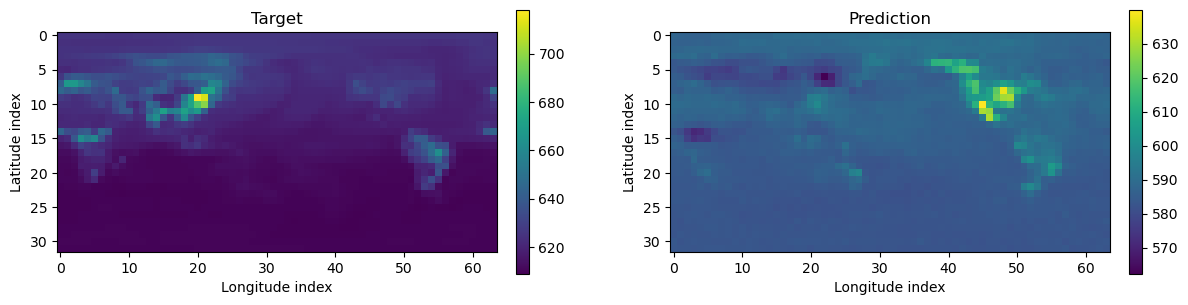

In [20]:
vlev = 0
nlat, nlon = 32, 64

target_2d = target[:, vlev].reshape(nlat, nlon)
pred_2d = pred[:, vlev].reshape(nlat, nlon)
pred_trajectory = pred_trajectory.reshape(nlev, nlat, nlon, -1)
pred_2d_trajectory = pred_trajectory[vlev, :, :, -1]

# vmin = min(target_2d.min(), pred_2d.min())
# vmax = max(target_2d.max(), pred_2d.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot target
im0 = axes[0].imshow(target_2d[::-1], cmap="viridis") #, vmin=vmin, vmax=vmax
axes[0].set_title("Target")
axes[0].set_xlabel("Longitude index")
axes[0].set_ylabel("Latitude index")
fig.colorbar(im0, ax=axes[0], fraction=0.028, pad=0.04)

# Plot prediction
im1 = axes[1].imshow(pred_2d[::-1], cmap="viridis") #, vmin=vmin, vmax=vmax
axes[1].set_title("Prediction")
axes[1].set_xlabel("Longitude index")
axes[1].set_ylabel("Latitude index")
fig.colorbar(im1, ax=axes[1], fraction=0.028, pad=0.04)

# Adjust horizontal spacing between subplots
plt.subplots_adjust(wspace=0.3)

plt.savefig("flowmatching_target_prediction.png")
plt.show()


In [21]:
print("Target min/max:", target.min(), target.max())
print("Pred   min/max:", pred.min(), pred.max())
print("Traj.  min/max:", pred_2d_trajectory.min(), pred_2d_trajectory.max())

Target min/max: 595.88873 718.141
Pred   min/max: 562.29956 639.9541
Traj.  min/max: -3.5657773 3.2461789


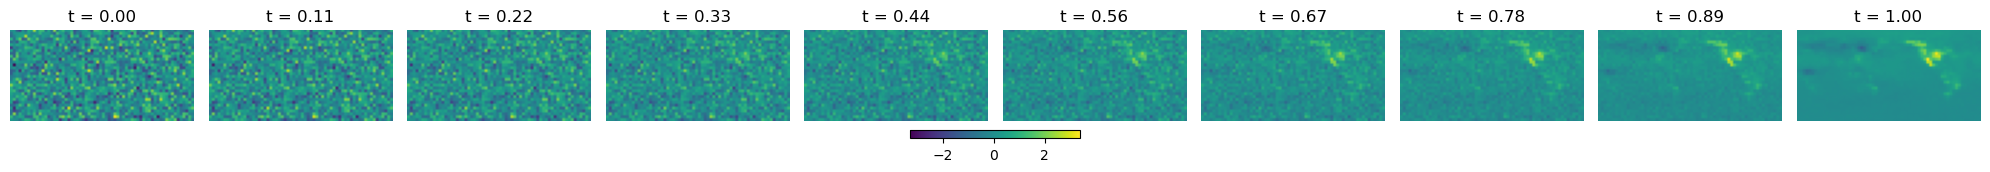

In [22]:
# trajectory.shape: (T=10, B=32, N=2048, C=10) -> one batch (B=0), surface level (C=0)

trajectory = output["trajectory"]  # [T B N C]
T, B, N, C = trajectory.shape
trajectory = trajectory.reshape(T, B, nlat, nlon, C)
sol_surface = trajectory[:, 0, :, :, 0]  # shape: [T, Nlat, Nlon]
sol_surface_flipped = torch.flip(sol_surface, dims=[1])

# plot
fig, axs = plt.subplots(1, T, figsize=(20, 2))

vmin, vmax = sol_surface_flipped.min(), sol_surface_flipped.max()
for i in range(T):
    im = axs[i].imshow(sol_surface_flipped[i, :, :], cmap="viridis", vmin=vmin, vmax=vmax)
    axs[i].set_title(f"t = {i/9:.2f}")
    axs[i].axis("off")

plt.tight_layout()
plt.colorbar(im, ax=axs, orientation='horizontal', fraction=0.05, pad=0.05)

plt.savefig("flowmatching_trajectory.png")
plt.show()

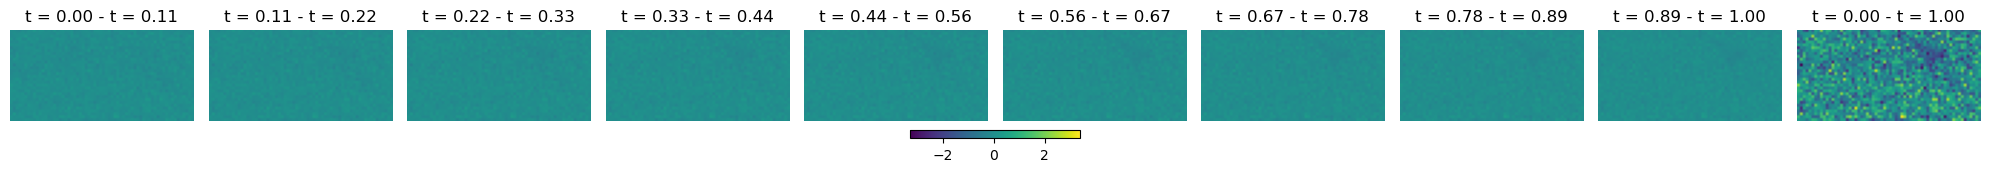

In [23]:
# Print differences between trajectory steps

# plot
fig, axs = plt.subplots(1, T, figsize=(20, 2))

for i in range(T-1):
    im = axs[i].imshow(sol_surface_flipped[i, :, :] - sol_surface_flipped[i+1, :, :], cmap="viridis", vmin=vmin, vmax=vmax)
    axs[i].set_title(f"t = {i/9:.2f} - t = { (i+1)/9:.2f}")
    axs[i].axis("off")

im = axs[T-1].imshow(sol_surface_flipped[0, :, :] - sol_surface_flipped[T-1, :, :], cmap="viridis", vmin=vmin, vmax=vmax)
axs[T-1].set_title(f"t = {0/9:.2f} - t = {9/9:.2f}")
axs[T-1].axis("off")

plt.tight_layout()
plt.colorbar(im, ax=axs, orientation='horizontal', fraction=0.05, pad=0.05)

plt.show()

In [24]:
torch.round(sol_surface[0, :, :] - sol_surface[9, :, :], decimals=2)
# noise is changing over time!

tensor([[ 0.2900,  0.0900,  0.0100,  ..., -0.1800,  1.1200, -0.7000],
        [ 1.1800, -0.2300,  0.3200,  ..., -1.1300,  1.4100, -0.0300],
        [-0.6700,  2.2600, -0.8700,  ...,  1.2500, -0.2900, -0.3700],
        ...,
        [-1.1900, -0.6400,  0.1200,  ..., -0.0100,  1.7600,  0.0400],
        [-0.9500, -0.0100,  0.0500,  ..., -0.3800, -1.3500, -1.0000],
        [-0.1400, -0.0300, -1.6400,  ..., -1.5500, -0.6100,  0.8800]])

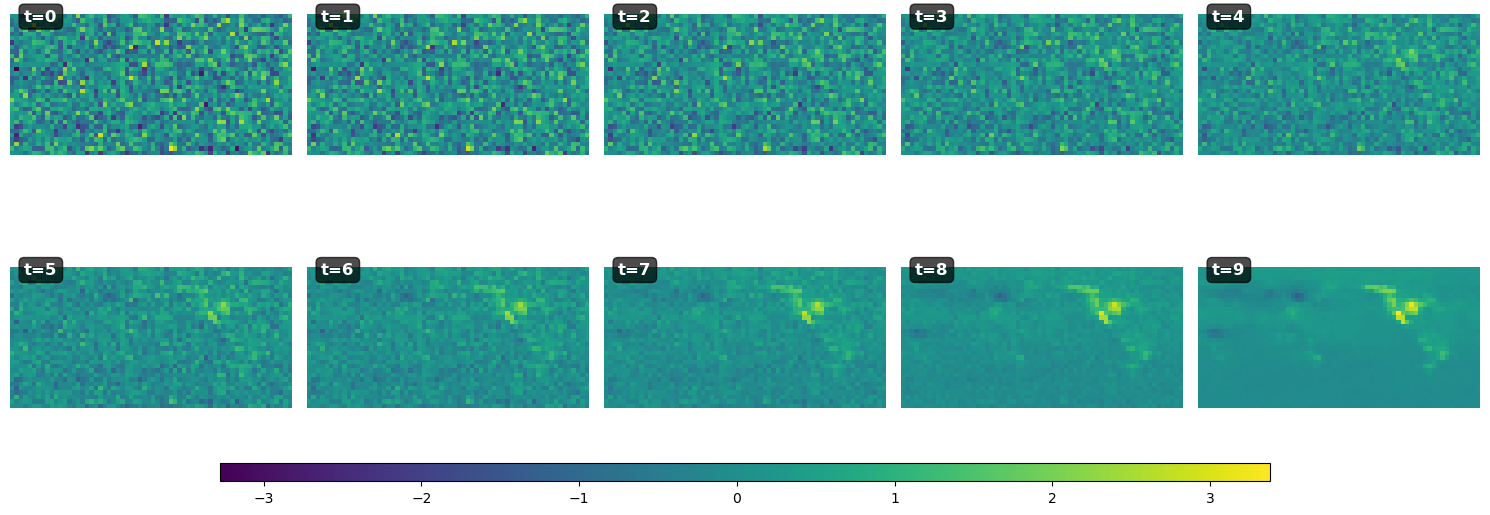

In [80]:
trajectory_vitus = output["trajectory"][:, 0, :, :].squeeze(1) # [T=10, N=2048, C=10]
trajectory_vitus = trajectory_vitus.view(trajectory_vitus.shape[0], nlat, nlon, trajectory_vitus.shape[-1]) # [T=10, Nlat=32, Nlon=64, C=10]
trajectory_vitus = trajectory_vitus.cpu().numpy()

# Plot a timeseries of maps of the trajectory for a given level
level_to_plot = 0  # Choose a level to plot
nsteps = trajectory_vitus.shape[0]

# Create a clean flow visualization with two rows
ncols = nsteps // 2 if nsteps % 2 == 0 else (nsteps + 1) // 2
nrows = 2 if nsteps > ncols else 1

fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))

# Handle different cases for axes indexing
if nrows == 1:
    if ncols == 1:
        axes = [axes]
    else:
        axes = axes.reshape(1, -1)
elif ncols == 1:
    axes = axes.reshape(-1, 1)

# Find global min/max for consistent colormap
vmin = trajectory_vitus[:, :, :, level_to_plot].min()
vmax = trajectory_vitus[:, :, :, level_to_plot].max()

for i in range(nsteps):
    row = i // ncols
    col = i % ncols

    if nrows == 1:
        ax = axes[col] if ncols > 1 else axes[0]
    else:
        ax = axes[row, col]

    im = ax.imshow(
        trajectory_vitus[i, :, :, level_to_plot],
        origin="lower",
        vmin=vmin,
        vmax=vmax,
        cmap="viridis",
    )

    # Remove all axis elements
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_visible(False)

    # Optional: add step number as text overlay
    ax.text(
        0.05,
        0.95,
        f"t={i}",
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        color="white",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.7),
    )

# Hide any unused subplots
if nsteps < nrows * ncols:
    for i in range(nsteps, nrows * ncols):
        row = i // ncols
        col = i % ncols
        if nrows == 1:
            axes[col].set_visible(False)
        else:
            axes[row, col].set_visible(False)

# Add horizontal colorbar below
plt.subplots_adjust(bottom=0.2)
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.03])
fig.colorbar(im, cax=cbar_ax, orientation="horizontal")

plt.tight_layout()
plt.show()

# Generative predictions

In [71]:
def plot_specific_noise_samples(
        ds,
        var="co2massmix",
        level=None,
        cmap="bone_r",
        params=None,
        param_name="Sample",
        title=None,
        savefig=False,
        filename="noise_samples.png"):
    """
    Plot maps of different samples for a given variable from an xarray dataset.
    """
    data = ds[var]  # (level, lat, lon, sample)
    
    if level is None:
        # Average over levels
        data_to_plot = data.mean(dim="level")
        label_title = "XCO₂ [ppm]"

    else:
        data_to_plot = data.isel(level=level)
        label_title = "CO₂ [ppm]"

    
    n_samples = data_to_plot.sizes["sample"]
    
    # Choose subplot grid
    ncols = n_samples // 2 if n_samples % 2 == 0 else (n_samples + 1) // 2
    nrows = 2 if n_samples > ncols else 1
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
    
    # Handle axes indexing
    if nrows == 1 and ncols == 1:
        axes = [axes]
    elif nrows == 1:
        axes = axes.reshape(1, -1)
    elif ncols == 1:
        axes = axes.reshape(-1, 1)
    
    # Global vmin/vmax for consistent colormap
    # vmin = float(data_to_plot.min())
    # vmax = float(data_to_plot.max())
    
    for i in range(n_samples):
        row = i // ncols
        col = i % ncols
        ax = axes[row, col] if nrows > 1 else axes[col]
        
        im = ax.imshow(
            data_to_plot.isel(sample=i),
            origin="lower",
            cmap=cmap,
            # vmin=vmin,
            # vmax=vmax,
        )
        
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
        
        if params is not None:
            label = f"{param_name}={params[i]:.2f}"
        else:
            label = f"Sample={i}"

        ax.text(
            0.05, 0.95,
            label,
            transform=ax.transAxes,
            fontsize=12,
            fontweight="bold",
            color="white",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.7),
        )
    
    # Hide unused subplots
    if n_samples < nrows * ncols:
        for i in range(n_samples, nrows * ncols):
            row = i // ncols
            col = i % ncols
            if nrows > 1:
                axes[row, col].set_visible(False)
            else:
                axes[col].set_visible(False)
    
    # Shared colorbar below
    plt.subplots_adjust(bottom=0.2)
    cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.03])
    fig.colorbar(im, cax=cbar_ax, orientation="horizontal", label=label_title)

    if title:
        fig.suptitle(title, fontsize=16, fontweight="bold", y=0.95)

    if savefig:
        fig.savefig(filename, dpi=300, bbox_inches="tight")
    
    plt.tight_layout()
    plt.show()

### Toy Noise

In [27]:
x_init_custom = torch.zeros(target_2d.shape)

n_points = 10
angles = torch.linspace(0, 4*torch.pi, n_points)
radii = torch.linspace(0, 3.0, n_points)

spiral_noises = []
for r, a in zip(radii, angles):
    noise = x_init_custom.clone()
    # inject spiral in first channel
    noise[:, :] = r * torch.cos(a)  # shift everywhere
    spiral_noises.append(noise)

# for noise in spiral_noises:
#     preds = flow_model.model(batch, x_init=noise)

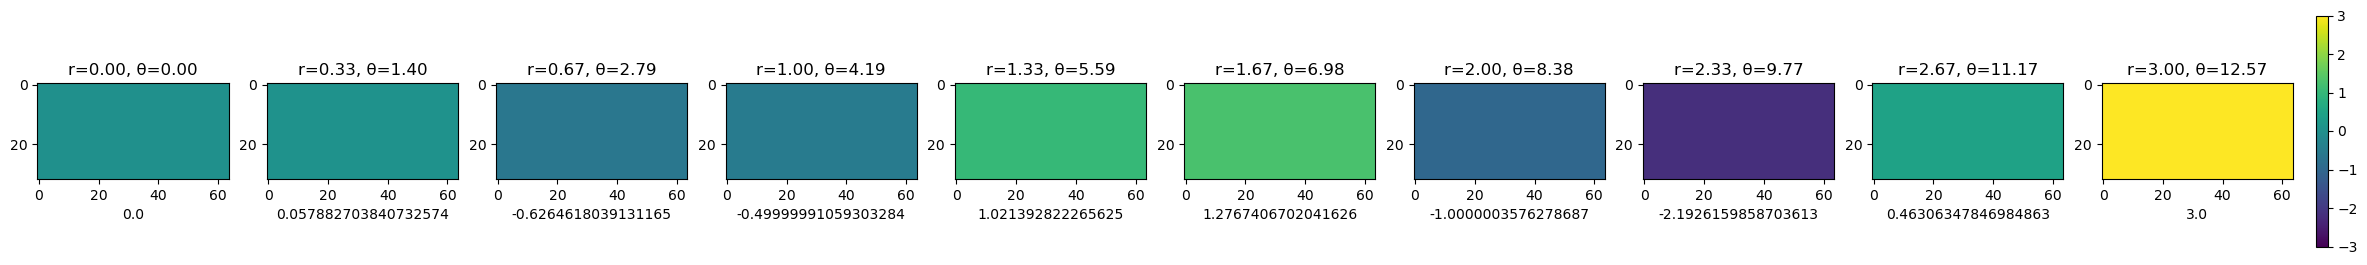

In [28]:
fig, axes = plt.subplots(1, n_points, figsize=(3*n_points, 3))
for i, noise in enumerate(spiral_noises):
    ax = axes[i]
    im = ax.imshow(noise.numpy(), cmap="viridis", vmin=-3, vmax=3)
    ax.set_title(f"r={radii[i]:.2f}, θ={angles[i]:.2f}")
    # ax.axis("off")
    ax.xaxis.set_visible(True)
    ax.set_xlabel(f"{noise[0, 0]}")
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.01)
plt.show()

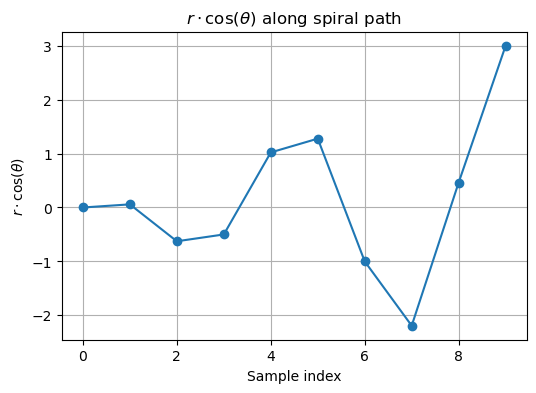

In [29]:
values = radii * torch.cos(angles)

plt.figure(figsize=(6, 4))
plt.plot(values.numpy(), marker="o")
plt.title(r"$r \cdot \cos(\theta)$ along spiral path")
plt.xlabel("Sample index")
plt.ylabel(r"$r \cdot \cos(\theta)$")
plt.grid(True)
plt.show()


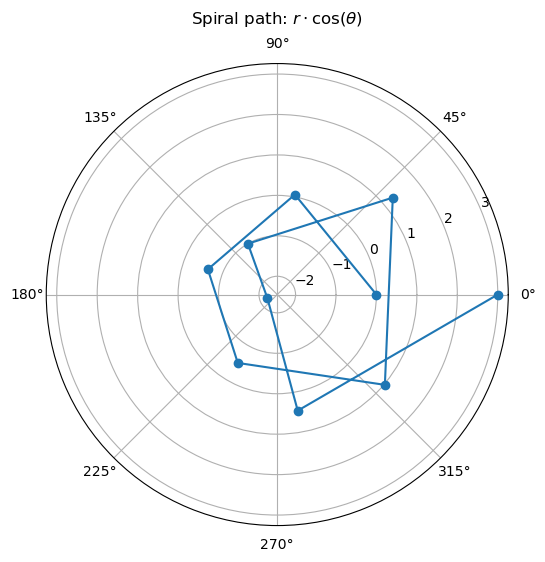

In [30]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, polar=True)
ax.plot(angles.numpy(), values.numpy(), marker="o")
ax.set_title(r"Spiral path: $r \cdot \cos(\theta)$", va='bottom')
plt.show()

In [31]:
def generate_noise(batch, n_samples=10, noise=None):

    all_levels = batch["co2massmix"].reshape(B, nlat, nlon, C)
    all_levels = all_levels.permute(0, 3, 1, 2)

    if noise is None:
        return [torch.randn_like(all_levels) for _ in range(n_samples)]
    
    elif noise == "spiral_noise":
        x0 = torch.randn_like(all_levels)
        v = torch.randn_like(all_levels)
        x0_unit = x0 / x0.norm()
        v_unit = v / v.norm()
        angles = torch.linspace(0, 4*torch.pi, n_samples)

        spiral_noises = []
        for a in angles:
            x_init = torch.cos(a) * x0_unit + torch.sin(a) * v_unit
            spiral_noises.append(x_init)
        return spiral_noises

    elif noise == "hypersphere_noise":
        # Step 1: pick a reference noise vector
        x0 = torch.randn_like(all_levels)
        # Step 2: pick a direction vector (independent random noise)
        v = torch.randn_like(all_levels)
        # Step 3: normalize both to have unit norm
        x0_unit = x0 / x0.norm()
        v_unit = v / v.norm()
        angles = torch.linspace(0, 4*torch.pi, n_samples)

        spiral_noises = []
        for a in angles:
            # Step 4: rotate between x0 and v
            x_init = torch.cos(a) * x0_unit + torch.sin(a) * v_unit
            # Step 5: scale radius outward
            r = 1.0 + 0.2 * (a / angles[-1])  # gradually increase radius
            x_init_scaled = r * x_init
            spiral_noises.append(x_init_scaled)
        return spiral_noises
    elif noise == "simple":
        x0 = torch.randn_like(all_levels)
        v = torch.randn_like(all_levels)
        alphas = torch.linspace(0, 1, n_samples)
        return [(1 - alpha) * x0 + alpha * v for alpha in alphas]
    else:
        raise ValueError(f"Unknown noise type: {noise}")

In [32]:
n_samples = 10

spiral_noises = generate_noise(batch_val, n_samples=n_samples, noise="spiral_noise")

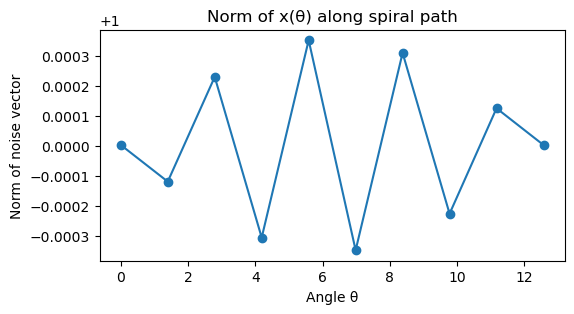

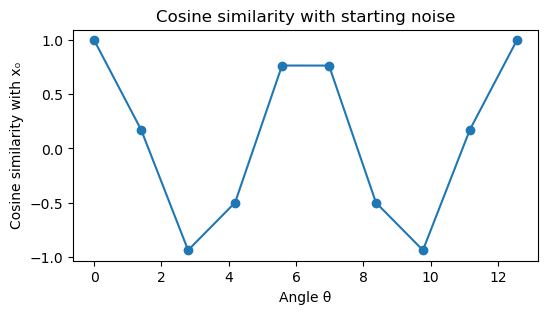

In [33]:
norms = torch.tensor([x.norm().item() for x in spiral_noises])
cosine_sims = [torch.nn.functional.cosine_similarity(spiral_noises[0].flatten(), x.flatten(), dim=0).item()
               for x in spiral_noises]

fig, ax1 = plt.subplots(figsize=(6, 3))
ax1.plot(angles.cpu(), norms, marker="o")
ax1.set_ylabel("Norm of noise vector")
ax1.set_xlabel("Angle θ")
ax1.set_title("Norm of x(θ) along spiral path")
plt.show()

fig, ax2 = plt.subplots(figsize=(6, 3))
ax2.plot(angles.cpu(), cosine_sims, marker="o")
ax2.set_ylabel("Cosine similarity with x₀")
ax2.set_xlabel("Angle θ")
ax2.set_title("Cosine similarity with starting noise")
plt.show()

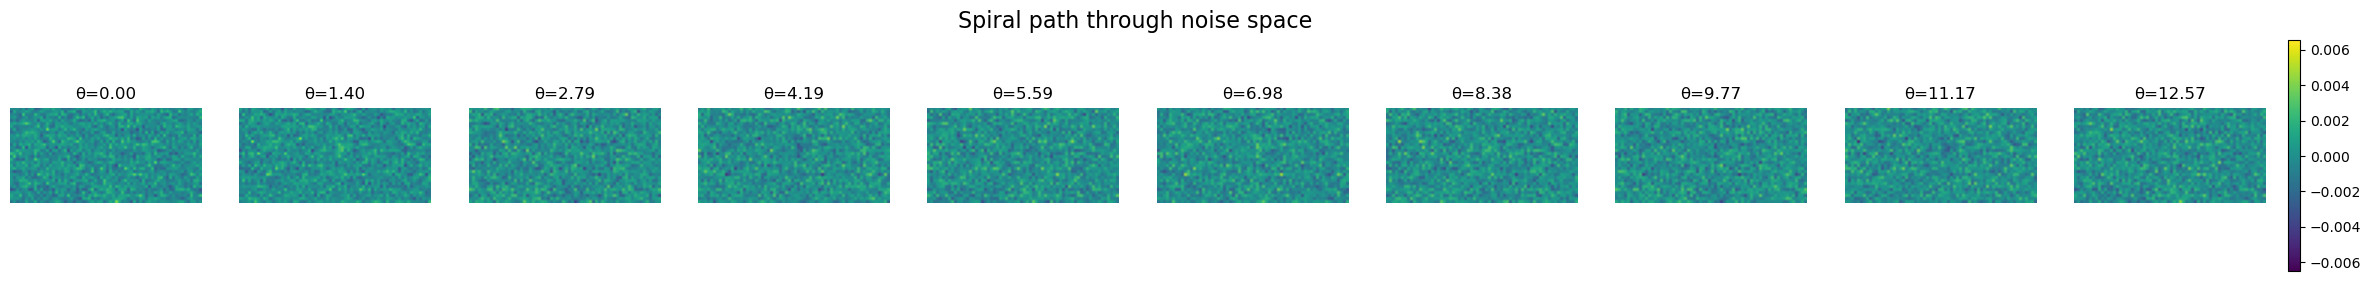

In [34]:
fig, axes = plt.subplots(1, n_points, figsize=(3*n_points, 3))
vmin = min([x.min() for x in spiral_noises]).item()
vmax = max([x.max() for x in spiral_noises]).item()

for i, x in enumerate(spiral_noises):
    ax = axes[i]
    im = ax.imshow(x[0, 0].cpu(), cmap="viridis", vmin=vmin, vmax=vmax)
    ax.set_title(f"θ={angles[i]:.2f}")
    ax.axis("off")

fig.colorbar(im, ax=axes, fraction=0.02, pad=0.01)
plt.suptitle("Spiral path through noise space", fontsize=16)
plt.show()

In [35]:
def analyze_noise_path(noises, angles, label="θ"):
    """
    Analyze a sequence of high-dimensional noise tensors.
    Plots norms, cosine similarity, and optional PCA projection.
    """
    noises_flat = [x.flatten().cpu() for x in noises]
    norms = torch.tensor([x.norm().item() for x in noises_flat])
    cosine_sims = [
        torch.nn.functional.cosine_similarity(noises_flat[0], x, dim=0).item()
        for x in noises_flat
    ]

    # Norm vs θ
    plt.figure(figsize=(6, 3))
    plt.plot(angles.cpu(), norms, marker="o")
    plt.ylabel("Norm of noise vector")
    plt.xlabel(label)
    plt.title(f"Norm of x({label}) along path")
    plt.grid(True)
    plt.show()

    # Cosine similarity vs θ
    plt.figure(figsize=(6, 3))
    plt.plot(angles.cpu(), cosine_sims, marker="o")
    plt.ylabel("Cosine similarity with start")
    plt.xlabel(label)
    plt.title(f"Cosine similarity with starting noise")
    plt.grid(True)
    plt.show()

    # PCA projection (optional)
    from sklearn.decomposition import PCA
    X = torch.stack(noises_flat).numpy()
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    plt.figure(figsize=(5, 5))
    plt.plot(X_pca[:, 0], X_pca[:, 1], marker="o")
    for i, a in enumerate(angles):
        plt.text(X_pca[i, 0], X_pca[i, 1], f"{a:.2f}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("Noise path projected via PCA")
    plt.show()

In [36]:
def load_dataset(data_path, data_kwargs):

    dataset = CarbonDataset(
        data_path=data_path,
        dataset=data_kwargs["dataset"],
        grid=data_kwargs["grid"],
        vertical_levels=data_kwargs["vertical_levels"],
        freq=data_kwargs["freq"],
        n_timesteps=1,
        target_vars=data_kwargs["target_vars"],
        forcing_vars=data_kwargs["forcing_vars"],
        load_obspack=True,
        new_zarr=True,
    )

    return dataset

data_path_forecast = Path(
    "/Net/Groups/BGI/tscratch/vbenson/graph_tm/data/Carbontracker/test/"
)

dataset = load_dataset(data_path_forecast, data_kwargs) # {k: [T, N, C]}

In [37]:
from typing import Optional

import torch.nn as nn

from neural_transport.models.regulargrid import RegularGridModel
from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import ODESolver
from neural_transport.models import MODELS

class VelocityWrapper(nn.Module):
    def __init__(
        self,
        submodel: nn.Module,
        nlev: int = 1,
        static_inputs: Optional[torch.Tensor] = None,
    ):
        super().__init__()
        self.submodel = submodel
        self.nlev = nlev
        self.static_inputs = static_inputs if static_inputs is not None else torch.empty(0)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        B, _, Nlat, Nlon = x.shape
        t_expanded = t.view(1, 1, 1, 1).expand(B, 1, Nlat, Nlon)
        if self.static_inputs.numel() > 0:
            static_inputs = self.static_inputs.to(x.device)
            x_in = torch.cat([x, t_expanded, static_inputs], dim=1) # [B C_total Nlat Nlon]
        else:
            x_in = torch.cat([x, t_expanded], dim=1)
        out = self.submodel.model(x_in)
        return out[:, :self.nlev, :, :]


class FlowMatching(RegularGridModel):
    def init_model(
            self,
            submodel="unet",
            model_kwargs={},
            return_intermediates=False,
            method='midpoint',
            nlev=1,
            step_size=0.01,
            ):
        
        self.submodel = MODELS[submodel](**model_kwargs)
        self.return_intermediates = return_intermediates
        self.method = method
        self.nlev = nlev
        self.step_size = step_size
        self.path = AffineProbPath(scheduler=CondOTScheduler())
        self.target_vars = self.submodel.target_vars # Here target_vars[0] is supposed to be "co2massmix"

    def forward(self, batch):
        if self.training:
            x_out, dx_t = self.training_forward(batch)
            preds = self.postprocess_outputs(x_out, batch, denormalize=False)
            preds["dx_t"] = dx_t.permute(0, 2, 3, 1).reshape(*preds[self.target_vars[0]].shape) # [B N C]
            return preds
        elif self.return_intermediates:
            x_in = self.preprocess_inputs(batch)
            trajectory = self.model(x_in)
            x_out = trajectory[-1,...]
            sol = self.postprocess_outputs(x_out, batch)
            T, B, C, Nlat, Nlon = trajectory.shape
            trajectory = trajectory.permute(0, 1, 3, 4, 2) # [T B Nlat Nlon C]
            trajectory = trajectory.reshape(T, B, Nlat*Nlon, C) # [T B Nlat*Nlon C]
            sol["trajectory"] = trajectory
            return sol
        else:
            return super().forward(batch)

    # training
    def training_forward(self, batch):
        # sample data [B C Nlat Nlon]
        x_in = self.preprocess_inputs(batch)
        # extract target_vars to get x_1 [B C Nlat Nlon] and normalize
        batch_normalized = self.normalize_batch_target_vars(batch)
        x_1_normalized = batch_normalized[f"{self.target_vars[0]}_next"]
        B, _, C = x_1_normalized.shape
        x_1_normalized = x_1_normalized.reshape(B, self.nlat, self.nlon, C).permute(0, 3, 1, 2)

        # sample noise  x_0 ~ N(0, I), [B C Nlat Nlon]
        x_0 = torch.randn_like(x_in, device=x_in.device)

        # sample time t \in [0,1], [B] -> [B 1 Nlat Nlon]
        B, _, nlat, nlon = x_in.shape
        t = torch.rand(B, device=x_in.device)

        # sample path
        path_sample = self.path.sample(
            t=t,
            x_0=x_0,
            x_1=x_1_normalized
        )

        # sample x_t from the path
        x_t = path_sample.x_t
        # x_t = path_sample.x_t + x_0 (simplified version)
        # this requires target_vars to be first in input_vars and all nlev-dimensional
        x_in[:, :self.nlev*len(self.target_vars), :, :] = x_t  # [B C Nlat Nlon] 

        t_expanded = path_sample.t.view(-1, 1, 1, 1).expand(B, 1, nlat, nlon)
        x_in = torch.cat([x_in, t_expanded], dim=1)  # [B C+1 Nlat Nlon]

        x_out = self.submodel.model(x_in)

        dx_t = path_sample.dx_t

        # # access scheduler for affine path
        # scheduler_out = self.path.scheduler(t)
        # d_sigma_t = scheduler_out.d_sigma_t.view(-1, 1, 1, 1)
        # d_alpha_t = scheduler_out.d_alpha_t.view(-1, 1, 1, 1)

        # x_out = (x_out - d_sigma_t * x_0) / d_alpha_t # to adjust for loss function definition

        return x_out, dx_t #, x_1_normalized # return {self.target_vars[0]: x_out}

    def return_velocity_wrapper(self, submodel, static_inputs=None):
        return VelocityWrapper(
            submodel=submodel,
            nlev=self.nlev,
            static_inputs=static_inputs,
        )

    # inference_forward
    def model(self, x_in):
        # sample noise to get x_init [B C Nlat Nlon]
        all_levels = x_in[:, :self.nlev*len(self.target_vars), :, :]  # [B C Nlat Nlon]
        #surface_level = x_in[:, :1, :, :]  # [B 1 Nlat Nlon]
        if "noise" in x_in:
            x_init = x_in["noise"]
        else:
            x_init = torch.randn_like(all_levels, device=x_in.device)
            #x_init = torch.randn(*surface_level.shape, device=batch[self.target_vars].device)

        # get timesteps for integration [T]
        time_grid = torch.linspace(0, 1, steps=10, device=x_init.device)

        # UNet expects normalization parameters
        velocity_model = self.return_velocity_wrapper(
            submodel=self.submodel,
            # static_inputs=x_in[:, self.nlev*len(self.target_vars):, :, :],  # [B C Nlat Nlon] (static inputs)
        )

        # solve the ODE to get the trajectory
        solver = ODESolver(velocity_model=velocity_model)
        trajectory = solver.sample(time_grid=time_grid,
                            x_init=x_init, method=self.method,
                            step_size=self.step_size,
                            return_intermediates=self.return_intermediates
        ) # [T B C Nlat Nlon]
        return trajectory

In [78]:
import shutil
import tempfile
import time as pytime
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import xarray as xr
from cdo import Cdo
from tqdm import tqdm


def get_zarrpath_obspath(out_path, rollout, freq, zarr_filename=None, zero_surfflux=False):
    if zarr_filename is None:
        zarr_filename = (
            f"co2_pred_rollout_{freq}.zarr" if rollout else "co2_pred_singlestep.zarr"
        )
    if zero_surfflux:
        zarr_filename = zarr_filename.replace("co2_pred", "co2_pred_zeroflux")

    out_path = Path(out_path)
    out_path.mkdir(exist_ok=True, parents=True)
    zarrpath = out_path / zarr_filename

    obspath = out_path / f"obs_{zarr_filename}"

    return zarrpath, obspath


def remap_with_cdo(dataset, prototype_zarr, ds):
    cdo = Cdo()
    prototype_zarr.lat.attrs = {
        "long_name": "latitude",
        "units": "degrees_north",
        "standard_name": "latitude",
    }
    prototype_zarr.lon.attrs = {
        "long_name": "longitude",
        "units": "degrees_east",
        "standard_name": "longitude",
    }

    ds["clon_vertices"] = dataset.grid_ds.clon_vertices
    ds["clat_vertices"] = dataset.grid_ds.clat_vertices
    ds["clon"] = dataset.grid_ds.clon
    ds["clat"] = dataset.grid_ds.clat
    ds["co2massmix"].attrs = {"CDI_grid_type": "unstructured"}
    ds["co2density"].attrs = {"CDI_grid_type": "unstructured"}
    ds["time"].attrs = {"standard_name": "time"}
    ds["height"].attrs = {"standard_name": "air_pressure"}

    grid_temp_file = tempfile.NamedTemporaryFile(
        delete=True, prefix="grid_temp_file_", dir=tempfile.gettempdir()
    )
    prototype_zarr.to_netcdf(grid_temp_file.name)

    ds_temp_file = tempfile.NamedTemporaryFile(
        delete=True, prefix="ds_temp_file_", dir=tempfile.gettempdir()
    )
    ds.transpose("time", "height", "cell", "nv").to_netcdf(ds_temp_file.name)

    ds_remap = cdo.remapcon(
        grid_temp_file.name, input=ds_temp_file.name, returnXDataset=True
    )

    grid_temp_file.close()
    ds_temp_file.close()

    cdo.cleanTempDir()
    return ds_remap


def generate_noise(batch, n_samples=10, noise=None):

    all_levels = batch["co2massmix"] # [T N C]
    all_levels = all_levels.unsqueeze(0) # [B T N C]

    if noise is None:
        return [torch.randn_like(all_levels) for _ in range(n_samples)]
    
    elif noise == "spiral_noise":
        x0 = torch.randn_like(all_levels)
        v = torch.randn_like(all_levels)
        angles = torch.linspace(0, 4*torch.pi, n_samples)

        spiral_noises = []
        for a in angles:
            x_init = torch.cos(a) * x0 + torch.sin(a) * v
            spiral_noises.append(x_init)
        return spiral_noises

    elif noise == "spiral_outward_noise":
        # Step 1: pick a reference noise vector
        x0 = torch.randn_like(all_levels)
        # Step 2: pick a direction vector (independent random noise)
        v = torch.randn_like(all_levels)
        # Step 3: create spiral path
        angles = torch.linspace(0, 4*torch.pi, n_samples)

        spiral_noises = []
        for a in angles:
            # Step 4: rotate between x0 and v
            x_init = torch.cos(a) * x0 + torch.sin(a) * v
            # Step 5: scale radius outward
            r = 1.0 + 0.5 * (a / angles[-1])  # gradually increase radius
            x_init_scaled = r * x_init
            spiral_noises.append(x_init_scaled)
        return spiral_noises
    elif noise == "geodesic_noise":
        x0 = torch.randn_like(all_levels)
        v = torch.randn_like(all_levels)
        alphas = torch.linspace(0, 1, n_samples)
        return [(1 - alpha) * x0 + alpha * v for alpha in alphas]
    else:
        raise ValueError(f"Unknown noise type: {noise}")


def iterative_generate(
    model,
    dataset,
    outpath,
    rollout=False,
    device="cuda",
    zarr_filename=None,
    freq=None,
    zero_surfflux=False,
    remap=False,
    target_vars_3d=[],
    target_vars_2d=[],
    save_obs=True,
    n_samples=10,
):
    zarrpath, obspath = get_zarrpath_obspath(outpath, rollout, freq, zarr_filename, zero_surfflux = zero_surfflux)

    prototype_zarr = dataset.create_prototype_zarr(
        zarrpath,
        target_vars_3d=target_vars_3d,
        target_vars_2d=target_vars_2d,
        grid="default" if remap else None,
    )

    model = model.eval().to(device)
    model.return_intermediates = True

    dss = []
    obss = []

    noise_list = generate_noise(dataset[0], n_samples=n_samples, noise="spiral_noise")
    angles = torch.linspace(0, 4*torch.pi, n_samples)
    # torch.linspace(0, 1, n_samples)  # alphas
    param_name = "$\\theta$"
    analyze_noise_path(noise_list, angles, label=param_name)
    
    for i in range(n_samples):
        batch = {k: v.unsqueeze(0).to(device) for k, v in dataset[0].items()} # condition on the first timestep
                
        batch["noise"] = noise_list[i].to(device)

        if zero_surfflux:
            for var in ["co2flux_anthro", "co2flux_land", "co2flux_ocean"]:
                batch[var] = torch.zeros_like(batch[var])

        with torch.no_grad():
            preds = model(batch)
            traj = preds["trajectory"]

        preds_fixed = {}
        for k, v in preds.items():
            if isinstance(v, list):
                v = v[0]
            preds_fixed[k] = v

        if save_obs:
            preds_fixed["gph_bottom"] = batch["gph_bottom"]
            preds_fixed["gph_top"] = batch["gph_top"]

        ds = xr.Dataset(
            {k: dataset.tensor_to_xarray(pred) for k, pred in preds_fixed.items()}
        )

        # ds = ds.assign_coords(
        #     time=prototype_zarr.time[:traj.shape[1]],
        #     sample=("sample", [i]),
        # )
        ds = ds.assign_coords(
            time=("time", prototype_zarr.time[:traj.shape[1]].values if traj.ndim > 0 else [0]),
            sample=("sample", [i]),
        )
        print(ds.dims)
        
        if remap:
            ds = remap_with_cdo(dataset, prototype_zarr.isel(time=0), ds)

        if save_obs:
            obs = dataset.readout_stations(ds, grid="default" if remap else None)
            ds = ds.drop_vars(["gph_bottom", "gph_top"])
            obss.append(obs)

        dss.append(ds)

    ds_all = xr.concat(dss, dim="sample")

    if save_obs:
        obs_all = xr.concat(obss, dim="sample").fillna({"obs_filename": ""})
        obs_all.to_zarr(obspath, mode="w")
        ds_all = ds_all.fillna({"obs_filename": ""})

    ds_all.to_zarr(zarrpath, mode="w")

    return ds_all

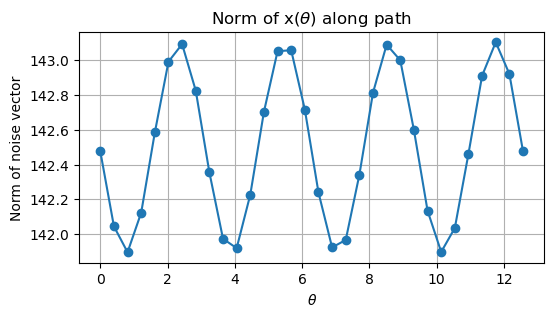

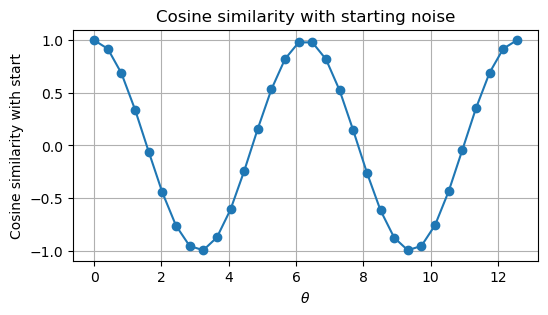

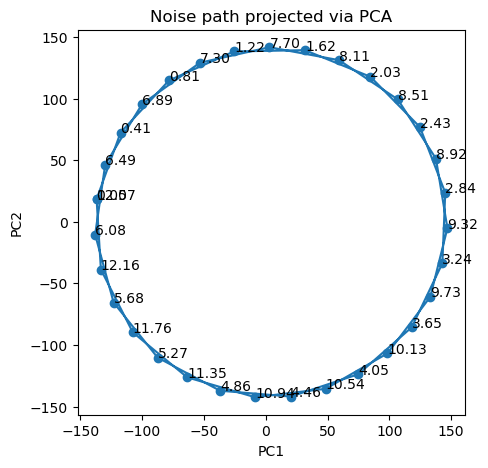

FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAc

In [106]:
n_samples = 32

outpath = Path("test_preds")
ds_all = iterative_generate(
    transport_model,
    dataset,
    outpath=outpath,
    rollout=False,
    device="cuda",
    zarr_filename=None,
    freq=None,
    zero_surfflux=False,
    remap=False,
    target_vars_3d=["co2massmix"],
    target_vars_2d=[],
    save_obs=False,   # True only possible if "gph_bottom", "gph_top" are in batch
    n_samples=n_samples,   # keep small for a test
)

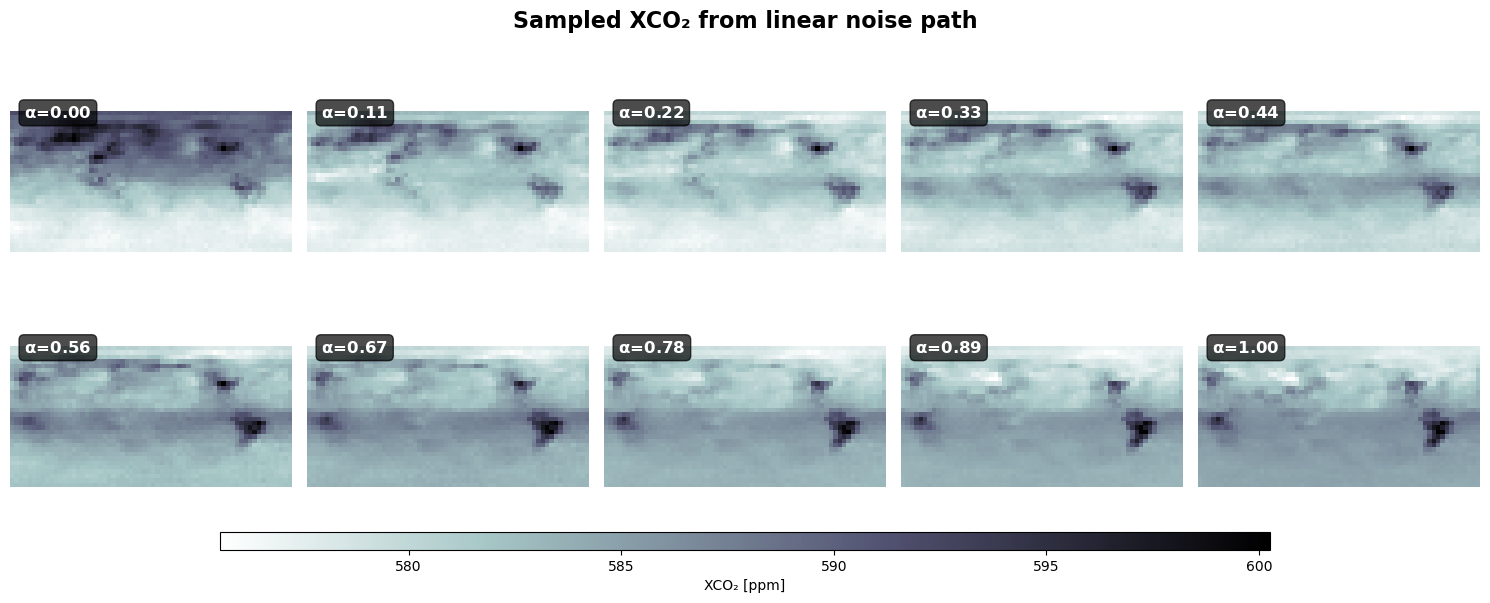

In [75]:
# noise_list = torch.linspace(0, 4*torch.pi, n_samples) # angles
# param_name = "$\\mathbf{\\theta}$"
noise_list = torch.linspace(0, 1, n_samples) # alphas
param_name = "$\\mathbf{\\alpha}$"

plot_specific_noise_samples(
    ds_all,
    var="co2massmix",
    params=noise_list,
    param_name=param_name,
    title="Sampled XCO₂ from linear noise path",
    savefig=True,
    filename="noise_samples_surface_linear.png")

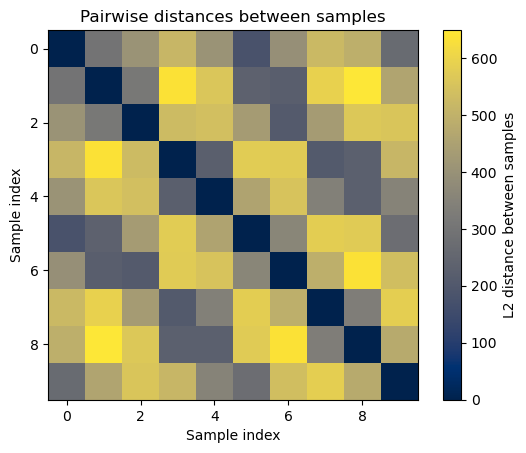

In [60]:
ds_slice = ds_all["co2massmix"].isel(level=0)

data = ds_slice.values  # shape: (10, lat, lon)
data_flat = data.reshape(data.shape[0], -1)

# Compute pairwise L2 distances
dist_matrix = np.linalg.norm(
    data_flat[:, None, :] - data_flat[None, :, :], axis=-1
)

plt.imshow(dist_matrix, cmap="cividis")
plt.colorbar(label="L2 distance between samples")
plt.title("Pairwise distances between samples")
plt.xlabel("Sample index")
plt.ylabel("Sample index")
plt.show()


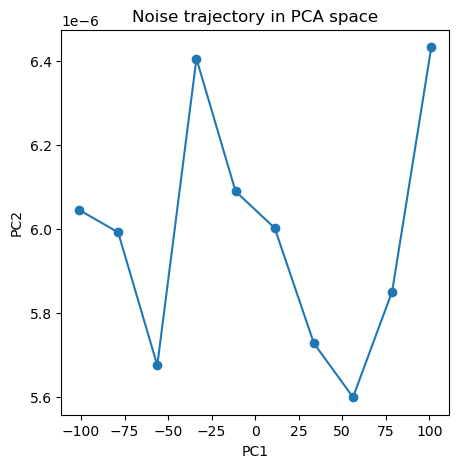

In [ ]:
from sklearn.decomposition import PCA

noise_list = generate_noise(dataset[0], n_samples=n_samples, noise="geodesic_noise")

# flatten noise tensors
noise_flat = torch.stack([n.flatten() for n in noise_list]).cpu().numpy()

pca = PCA(n_components=2)
noise_2d = pca.fit_transform(noise_flat)

plt.figure(figsize=(5,5))
plt.plot(noise_2d[:,0], noise_2d[:,1], marker="o")
plt.title("Noise trajectory in PCA space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

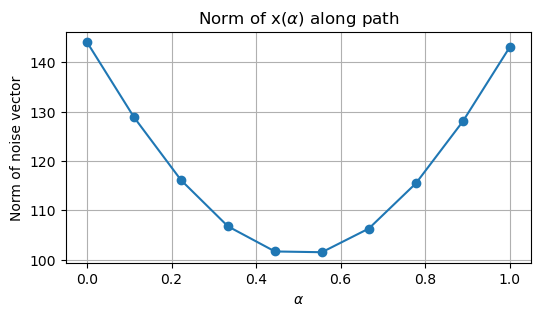

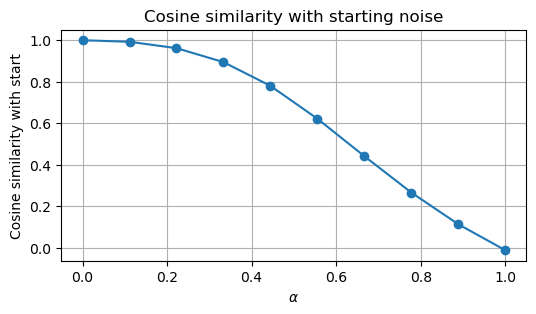

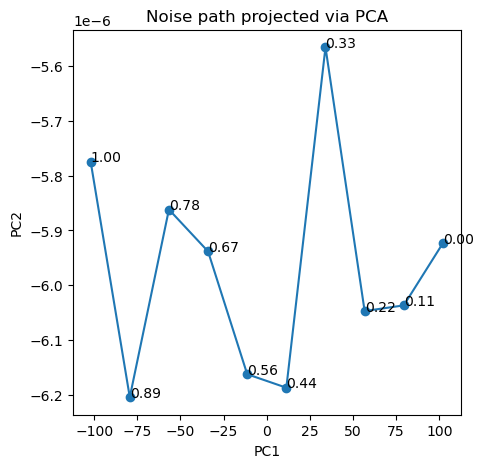

In [ ]:
# noises = generate_noise(dataset[0], n_samples=n_samples, noise="geodesic_noise")
# angles = torch.linspace(0, 1, n_samples)  # alphas
# param_name = "$\\alpha$"

# analyze_noise_path(noises, angles, label=param_name)

In [97]:
batch_val["co2massmix"].shape # [B=32, N=2048, C=10]

torch.Size([32, 2048, 10])

In [107]:
# calculate mean over space

# for training dataset 
# train_stack = torch.cat([d["co2massmix"] for d in dataset], dim=0) #  [samples=4383, N=2048, C=10]
# train_means = train_stack.mean(dim=1).numpy()  # [samples, C]
batch_tensor = batch_val["co2massmix"] # [B=32, N=2048, C=10]
batch_means = batch_tensor.mean(dim=1).numpy()  # [B, C]

# for predicted dataset
pred_means = ds_all["co2massmix"].mean(dim=["lat", "lon"]).values  # [sample, level]

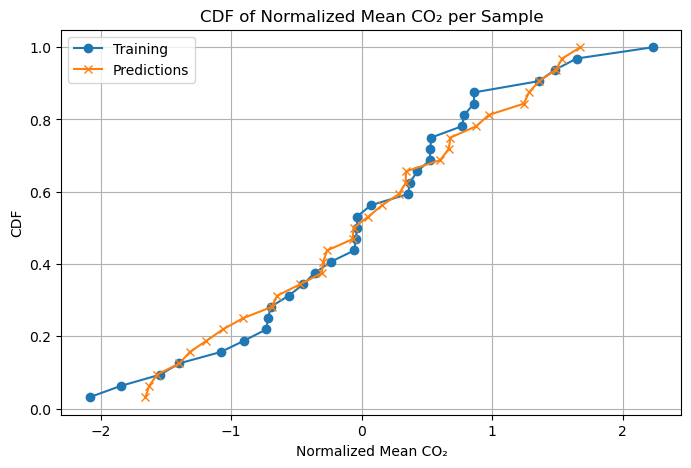

In [108]:
# Distribution of mean CO2 per sample across all levels

train_flat = batch_tensor.mean(dim=1).mean(dim=1).numpy()  # [B]
pred_flat = (
    ds_all["co2massmix"]
    .mean(dim=["lat", "lon"])   # → dims: (sample, level)
    .mean(dim="level")          # → dims: (sample,)
    .values
)  # [sample]

# Normalize each to zero mean, unit variance
train_norm = (train_flat - train_flat.mean()) / train_flat.std()
pred_norm = (pred_flat - pred_flat.mean()) / pred_flat.std()

plt.figure(figsize=(8,5))
plt.plot(np.sort(train_norm), np.arange(1,len(train_norm)+1)/len(train_norm), label="Training", marker='o')
plt.plot(np.sort(pred_norm), np.arange(1,len(pred_norm)+1)/len(pred_norm), label="Predictions", marker='x')
plt.xlabel("Normalized Mean CO₂")
plt.ylabel("CDF")
plt.title("CDF of Normalized Mean CO₂ per Sample")
plt.legend()
plt.grid(True)
plt.show()

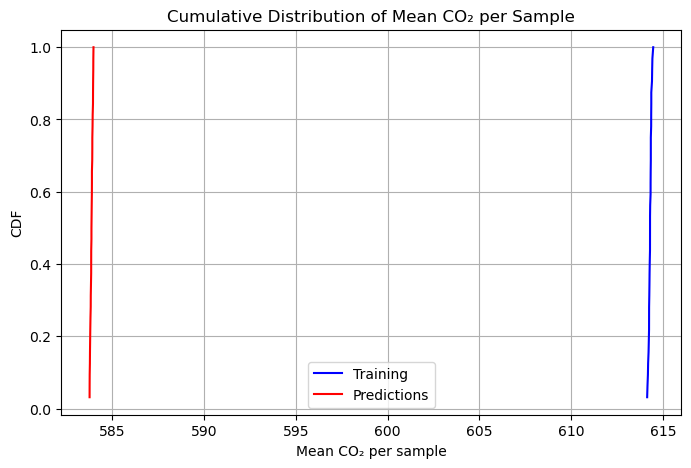

In [109]:
# Cumulative Distribution Function (CDF) of mean CO2 per sample

# Sort values
train_sorted = np.sort(train_flat)
pred_sorted = np.sort(pred_flat)

# Compute cumulative fraction
train_cdf = np.arange(1, len(train_sorted)+1) / len(train_sorted)
pred_cdf = np.arange(1, len(pred_sorted)+1) / len(pred_sorted)

plt.figure(figsize=(8,5))
plt.plot(train_sorted, train_cdf, label="Training", color="blue")
plt.plot(pred_sorted, pred_cdf, label="Predictions", color="red")
plt.xlabel("Mean CO₂ per sample")
plt.ylabel("CDF")
plt.title("Cumulative Distribution of Mean CO₂ per Sample")
plt.legend()
plt.grid(True)
plt.show()

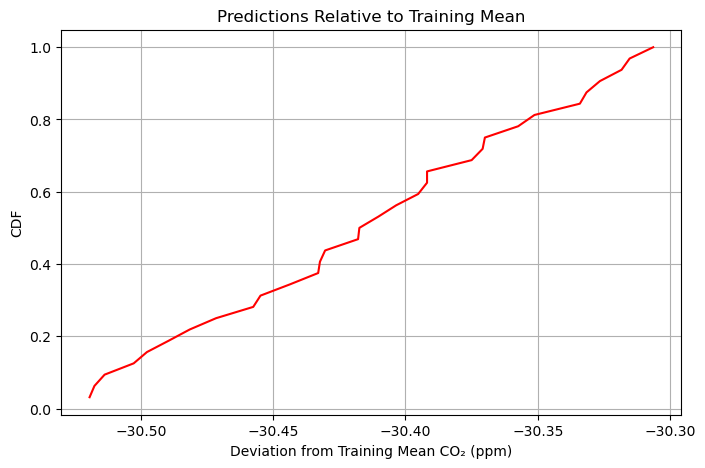

In [110]:
train_mean = train_flat.mean()
pred_centered = pred_flat - train_mean

plt.figure(figsize=(8,5))
plt.plot(np.sort(pred_centered), np.arange(1,len(pred_centered)+1)/len(pred_centered), label="Predictions centered", color="red")
plt.xlabel("Deviation from Training Mean CO₂ (ppm)")
plt.ylabel("CDF")
plt.title("Predictions Relative to Training Mean")
plt.grid(True)
plt.show()


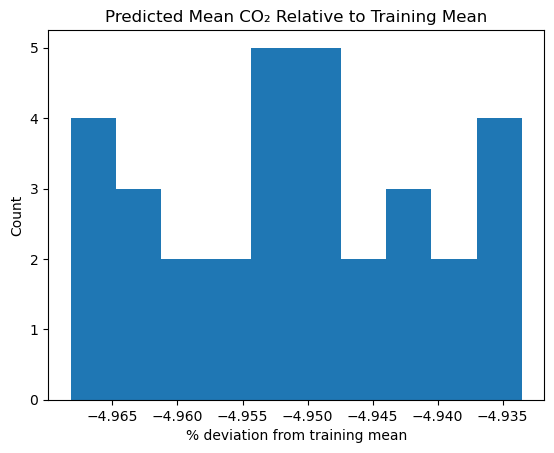

In [111]:
pred_rel = (pred_flat - train_flat.mean()) / train_flat.mean() * 100  # % deviation
plt.hist(pred_rel, bins=10)
plt.xlabel("% deviation from training mean")
plt.ylabel("Count")
plt.title("Predicted Mean CO₂ Relative to Training Mean")
plt.show()


### Toy batches for testing

In [ ]:
# print(f"keys of batch_val: {batch_val.keys()}")
# print(f"shape of batch_val['co2massmix']: {batch_val['co2massmix'].shape}") # [B=32, N=2048, C=10]
# print(f"length of batch_val: {len(batch_val)}")

# toy batch reduced to co2massmix only
toy_batch_co2massmix = {k: v.clone() for k, v in batch_val.items() if "co2massmix" in k}

nlat, nlon = 32, 64

# toy batch with values set to zero
toy_batch_zeros = {k: torch.zeros_like(v) for k, v in toy_batch_co2massmix.items()}

# toy batch with values set to 1
toy_batch_ones = {k: torch.ones_like(v) for k, v in toy_batch_co2massmix.items()}

# toy batch with values set to right and left
left = 0.0
right = 500.0
toy_batch_rl = {k: v.clone() for k, v in toy_batch_co2massmix.items()}

for k, v in toy_batch_rl.items():
    if "scale" not in k and "offset" not in k:
        v_reshaped = v.clone().reshape(v.shape[0], nlat, nlon, v.shape[-1]) 
        v_reshaped[:, :, :nlon//2, :] = left
        v_reshaped[:, :, nlon//2:, :] = right
        toy_batch_rl[k] = v_reshaped.reshape(v.shape)
    elif "scale" in k:
        toy_batch_rl[k] = torch.ones_like(v) * 250.0
    elif "offset" in k:
        toy_batch_rl[k] = torch.ones_like(v) * 250.0

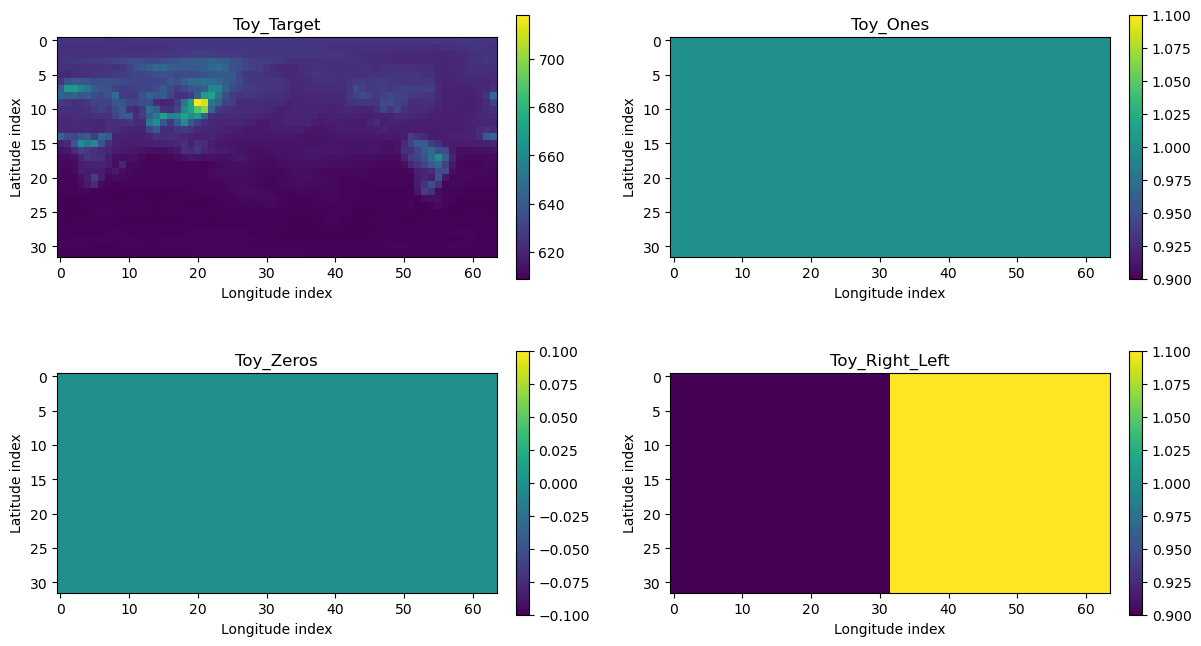

In [ ]:
# Plot toy batches

vlev = 0
nlat, nlon = 32, 64

toy_co2massmix = toy_batch_co2massmix["co2massmix"][0].cpu().numpy()
toy_target_2d = toy_co2massmix[:, vlev].reshape(nlat, nlon)
toy_zeros = toy_batch_zeros["co2massmix"][0].cpu().numpy()
toy_zeros_2d = toy_zeros[:, vlev].reshape(nlat, nlon)
toy_rl = toy_batch_rl["co2massmix"][0].cpu().numpy()
toy_rl_2d = toy_rl[:, vlev].reshape(nlat, nlon)

# vmin = min(target_2d.min(), pred_2d.min())
# vmax = max(target_2d.max(), pred_2d.max())

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Plot toy batch co2massmix
im0 = axes[0][0].imshow(toy_target_2d[::-1], cmap="viridis") #, vmin=vmin, vmax=vmax
axes[0][0].set_title("Toy_Target")
axes[0][0].set_xlabel("Longitude index")
axes[0][0].set_ylabel("Latitude index")
fig.colorbar(im0, ax=axes[0][0], fraction=0.028, pad=0.04)

# Plot toy batch zeros
im1 = axes[1][0].imshow(toy_zeros_2d[::-1], cmap="viridis") #, vmin=vmin, vmax=vmax
axes[1][0].set_title("Toy_Zeros")
axes[1][0].set_xlabel("Longitude index")
axes[1][0].set_ylabel("Latitude index")
fig.colorbar(im1, ax=axes[1][0], fraction=0.028, pad=0.04)

# Plot toy batch ones
im2 = axes[0][1].imshow(toy_zeros_2d[::-1] + 1, cmap="viridis") #, vmin=vmin, vmax=vmax
axes[0][1].set_title("Toy_Ones")
axes[0][1].set_xlabel("Longitude index")
axes[0][1].set_ylabel("Latitude index")
fig.colorbar(im2, ax=axes[0][1], fraction=0.028, pad=0.04)

# Plot toy batch right and left
im3 = axes[1][1].imshow(toy_rl_2d[::-1], cmap="viridis") #, vmin=vmin, vmax=vmax
axes[1][1].set_title("Toy_Right_Left")
axes[1][1].set_xlabel("Longitude index")
axes[1][1].set_ylabel("Latitude index")
fig.colorbar(im2, ax=axes[1][1], fraction=0.028, pad=0.04)

# Adjust horizontal spacing between subplots
plt.subplots_adjust(wspace=0.3)

plt.show()


In [ ]:
with torch.no_grad():
    toy_output = flow_model(toy_batch_rl)

RuntimeError: Input type (torch.FloatTensor) and weight type (torch.cuda.FloatTensor) should be the same or input should be a MKLDNN tensor and weight is a dense tensor

In [ ]:
vlev = 0
nlat, nlon = 32, 64

toy_target = toy_batch_rl["co2massmix"][0].cpu().numpy()
toy_pred = toy_output["co2massmix"][0].cpu().numpy()
toy_target_2d = toy_target[:, vlev].reshape(nlat, nlon)
toy_pred_2d = toy_pred[:, vlev].reshape(nlat, nlon)

# vmin = min(target_2d.min(), pred_2d.min())
# vmax = max(target_2d.max(), pred_2d.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot target
im0 = axes[0].imshow(toy_target_2d[::-1], cmap="viridis") #, vmin=vmin, vmax=vmax
axes[0].set_title("Toy_Target")
axes[0].set_xlabel("Longitude index")
axes[0].set_ylabel("Latitude index")
fig.colorbar(im0, ax=axes[0], fraction=0.028, pad=0.04)

# Plot prediction
im1 = axes[1].imshow(toy_pred_2d[::-1], cmap="viridis") #, vmin=vmin, vmax=vmax
axes[1].set_title("Toy_Prediction")
axes[1].set_xlabel("Longitude index")
axes[1].set_ylabel("Latitude index")
fig.colorbar(im1, ax=axes[1], fraction=0.028, pad=0.04)

# Adjust horizontal spacing between subplots
plt.subplots_adjust(wspace=0.3)

plt.show()


In [ ]:
# trajectory.shape: (T=10, B=32, N=2048, C=10) -> one batch (B=0), surface level (C=0)

toy_trajectory = toy_output["trajectory"]  # [T B N C]
toy_sol_surface = toy_trajectory[:, 0, :, 0] # [T, N]
toy_sol_surface = toy_sol_surface.permute(1, 0) # [N, T]
toy_sol_surface = toy_sol_surface.reshape(nlat, nlon, -1) # [Nlat, Nlon, T]
toy_sol_surface = torch.flip(toy_sol_surface, dims=[0])

# plot
fig, axs = plt.subplots(1, 10, figsize=(20, 2))

vmin, vmax = toy_sol_surface.min(), toy_sol_surface.max()
for i in range(10):
    im = axs[i].imshow(toy_sol_surface[:, :, i], cmap="viridis", vmin=vmin, vmax=vmax)
    axs[i].set_title(f"t = {i/9:.2f}")
    axs[i].axis("off")

plt.tight_layout()
plt.colorbar(im, ax=axs, orientation='horizontal', fraction=0.05, pad=0.05)

plt.show()